# SigAuth Complete Backend
## Advanced Forgery-Resilient Signature Authentication
### Siamese Metric Learning + Digital Tamper Detection
**Team:** Kosireddi Pavani | Duvvuri Sri Gayatri Sameera | Molagajje Jessy Priya  
**Guide:** Dr. Dwiti Krishna Bebarta | GVP College of Engineering for Women

---
### Notebook Structure
| Cell | Purpose |
|------|--------|
| 1 | Install dependencies |
| 2 | Imports and setup |
| 3 | Upload and extract datasets |
| 4 | Dataset validation and visualisation |
| 5 | Model definitions |
| 6 | Datasets and data loaders |
| 7 | Train Siamese Network |
| 8 | Train Tamper CNN |
| 9 | Evaluation: FAR/FRR/EER/AUC/F1 |
| 10 | Results visualisation |
| 11 | Save models and summary |
| 12 | Flask API + ngrok |


## Cell 1 - Install Dependencies

In [ ]:
import subprocess
print('Installing PyTorch with CUDA 11.8...')
subprocess.run('pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118', shell=True)
print('Installing auxiliary packages...')
subprocess.run('pip install -q flask flask-cors pyngrok pillow numpy scikit-learn matplotlib seaborn opencv-python-headless tqdm joblib scipy', shell=True)
print('All packages installed!')


Installing PyTorch with CUDA 11.8...
Installing auxiliary packages...
All packages installed!


## Cell 2 - Imports and Global Setup

In [ ]:
import os, sys, json, time, random, zipfile, shutil, base64, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from io import BytesIO
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
import joblib
from PIL import Image
from tqdm.notebook import tqdm
import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

BASE     = Path("/content")
DS_ROOT  = BASE / "datasets"
TASK1    = DS_ROOT / "svc2004" / "task1"
TASK2    = DS_ROOT / "svc2004" / "task2"
CLEAN    = DS_ROOT / "tamper" / "clean"
TAMPERED = DS_ROOT / "tamper" / "tampered"
MODELS   = BASE / "saved_models"
RESULTS  = BASE / "results"

for d in [TASK1, TASK2, CLEAN, TAMPERED, MODELS, RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

CFG = dict(
    siam_lr=1e-4, siam_epochs=60, siam_batch=32, siam_margin=1.0,
    siam_embed_dim=256, siam_patience=12, ngts=3,
    tamp_lr=1e-4, tamp_epochs=50, tamp_batch=32, tamp_patience=10,
    img_size=224, pca_components=40, alpha=0.5,
)
print("Config:", CFG)
print("Setup complete!")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Config: {'siam_lr': 0.0001, 'siam_epochs': 60, 'siam_batch': 32, 'siam_margin': 1.0, 'siam_embed_dim': 256, 'siam_patience': 12, 'ngts': 3, 'tamp_lr': 0.0001, 'tamp_epochs': 50, 'tamp_batch': 32, 'tamp_patience': 10, 'img_size': 224, 'pca_components': 40, 'alpha': 0.5}
Setup complete!


## Cell 3 - Upload and Extract Datasets
> Upload `task1.zip`, `task2.zip`, `synthetic_tamper.zip` in the Colab file panel first, then run this cell.

In [ ]:
def try_extract(candidates, dest):
    for p in candidates:
        p = Path(p)
        if p.exists():
            print(f"Extracting {p.name}...")
            with zipfile.ZipFile(p) as z:
                z.extractall(dest)
            print(f"  Done -> {dest}")
            return True
    print(f"  WARNING: Not found: {[str(c) for c in candidates]}")
    return False

try_extract(["/content/task1.zip", "/content/Task1.zip"], TASK1)
try_extract(["/content/task2.zip", "/content/Task2.zip"], TASK2)
try_extract(["/content/synthetic_tamper.zip", "/content/tamper.zip"], DS_ROOT / "tamper")

def flatten_images(folder):
    folder = Path(folder)
    for root, dirs, files in os.walk(str(folder)):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                src = Path(root) / f
                dst = folder / f
                if str(src) != str(dst):
                    shutil.move(str(src), str(dst))

for folder in [TASK1, TASK2]:
    sub = [d for d in folder.iterdir() if d.is_dir()]
    if sub:
        print(f"Flattening sub-folders in {folder.name}...")
        flatten_images(folder)

for sub in ["clean", "tampered"]:
    nested = DS_ROOT / "tamper" / "synthetic_tamper" / sub
    target = DS_ROOT / "tamper" / sub
    if nested.exists():
        target.mkdir(exist_ok=True)
        for f in nested.iterdir():
            shutil.move(str(f), str(target / f.name))

def count_images(p):
    return sum(1 for f in Path(p).rglob("*") if f.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp'])

print("\n=== DATASET SUMMARY ===")
for name, path in [("Task1", TASK1), ("Task2", TASK2), ("Clean", CLEAN), ("Tampered", TAMPERED)]:
    n = count_images(path)
    print(f"  {name:12s}: {n:6d} images")


Extracting Task1.zip...
  Done -> /content/datasets/svc2004/task1
Extracting Task2.zip...
  Done -> /content/datasets/svc2004/task2
Extracting synthetic_tamper.zip...
  Done -> /content/datasets/tamper

=== DATASET SUMMARY ===
  Task1       :   1600 images
  Task2       :   1600 images
  Clean       :   1000 images
  Tampered    :   1000 images


## Cell 4 - Dataset Validation and Visualisation

Task 1: 40 users
Task 2: 40 users
  Sample user -- genuine: 20, forgery: 20


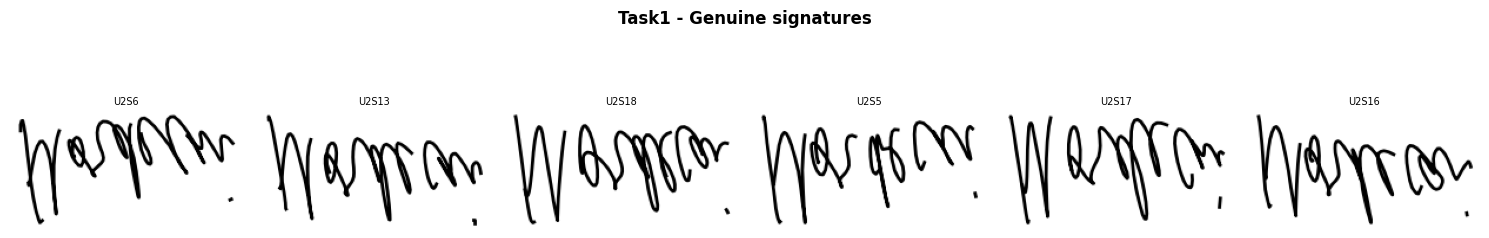

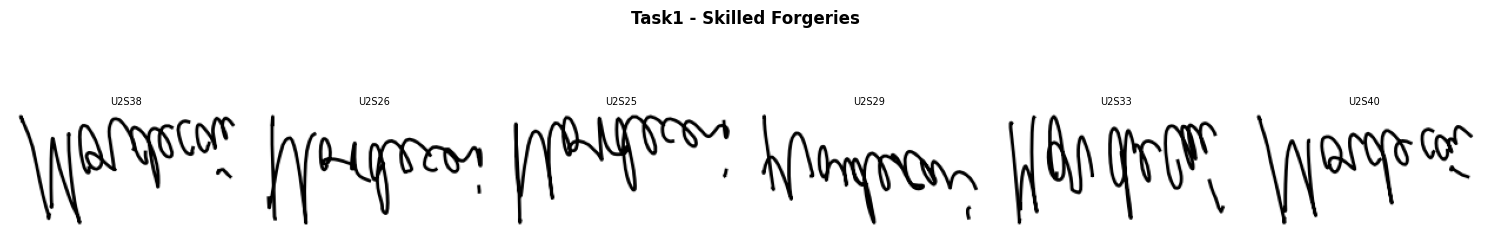

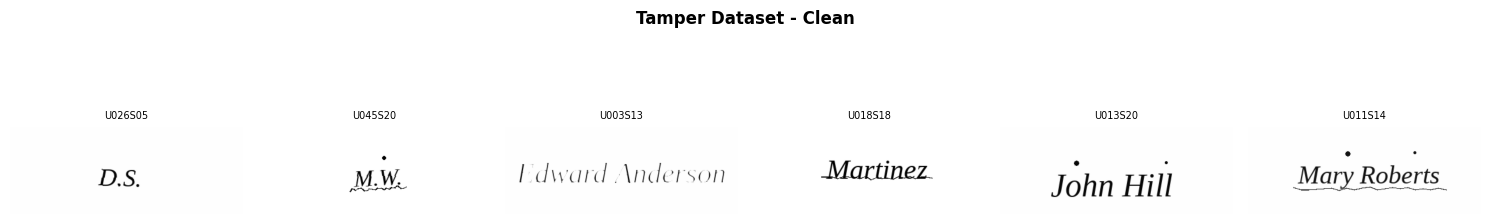

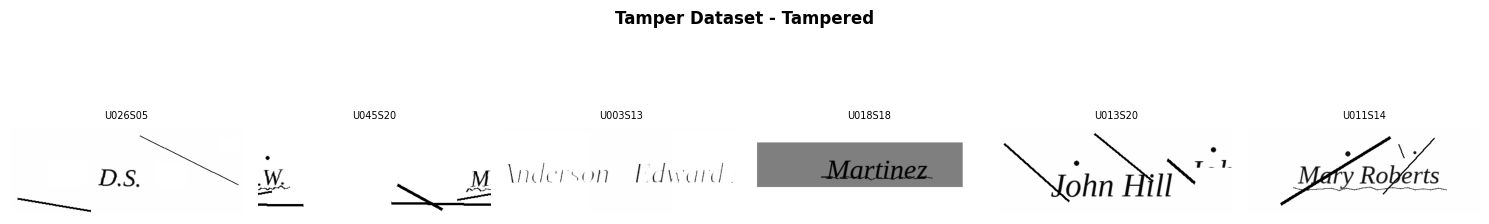

Validation complete!


In [ ]:
def parse_svc(folder):
    users = defaultdict(lambda: {"genuine": [], "forgery": []})
    for f in Path(folder).glob("*.png"):
        name = f.stem.upper()
        try:
            u_idx = name.index("U")
            s_idx = name.index("S")
            user   = int(name[u_idx+1:s_idx])
            sample = int(name[s_idx+1:])
            cat = "genuine" if sample <= 20 else "forgery"
            users[user][cat].append(f)
        except Exception:
            pass
    return users

users1 = parse_svc(TASK1)
users2 = parse_svc(TASK2)
print(f"Task 1: {len(users1)} users")
print(f"Task 2: {len(users2)} users")
if users1:
    u = list(users1.values())[0]
    print(f"  Sample user -- genuine: {len(u['genuine'])}, forgery: {len(u['forgery'])}")

def show_samples(title, image_paths, n=6):
    paths = list(image_paths)[:n]
    if not paths:
        return
    fig, axes = plt.subplots(1, len(paths), figsize=(len(paths)*2.5, 3))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        try:
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "N/A", ha='center', va='center')
        ax.axis('off')
        ax.set_title(Path(p).stem, fontsize=7)
    fig.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

if users1:
    u1 = list(users1.values())[0]
    show_samples("Task1 - Genuine signatures", u1["genuine"])
    if u1["forgery"]:
        show_samples("Task1 - Skilled Forgeries", u1["forgery"])

clean_imgs    = list(CLEAN.glob("*.png"))
tampered_imgs = list(TAMPERED.glob("*.png"))
if clean_imgs:
    show_samples("Tamper Dataset - Clean", clean_imgs[:6])
if tampered_imgs:
    show_samples("Tamper Dataset - Tampered", tampered_imgs[:6])

print("Validation complete!")


## Cell 5 - Model Definitions
- **EmbeddingNet**: ResNet-18 backbone fusing Res5b + Softmax (Prob) layers
- **SiameseNet**: Triplet network for skilled forgery detection
- **TamperCNN**: ResNet-18 + noise anomaly branch for digital tamper detection


In [ ]:
# ==========================================================
# EMBEDDING NETWORK (Res5b + Prob layer fusion -- base paper)
# ==========================================================
class EmbeddingNet(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        backbone   = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Res5b: last conv block before GAP
        self.res5b = nn.Sequential(*list(backbone.children())[:-2])
        # Prob: full backbone up to GAP (Softmax features)
        self.prob  = nn.Sequential(*list(backbone.children())[:-1])
        self.gap   = nn.AdaptiveAvgPool2d(1)
        feat_dim   = 512 + 512  # res5b(512) + prob(512)
        self.head  = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
        )

    def forward(self, x):
        feat5b    = self.gap(self.res5b(x)).flatten(1)  # (B,512)
        feat_prob = self.prob(x).flatten(1)             # (B,512)
        feat = torch.cat([feat5b, feat_prob], dim=1)   # (B,1024)
        return F.normalize(self.head(feat), p=2, dim=1)


# ==========================================================
# SIAMESE NETWORK (Triplet-loss metric learning)
# ==========================================================
class SiameseNet(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.emb = EmbeddingNet(embed_dim)

    def forward(self, a, p, n):
        return self.emb(a), self.emb(p), self.emb(n)

    def get_embedding(self, x):
        return self.emb(x)


# ==========================================================
# TAMPER DETECTION CNN (ResNet-18 + noise anomaly branch)
# ==========================================================
class TamperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Freeze early layers; fine-tune layer3, layer4, fc
        for name, param in backbone.named_parameters():
            param.requires_grad = any(k in name for k in ["layer3", "layer4", "fc"])
        in_feats   = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_feats, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
        )
        self.net = backbone
        # Pixel noise anomaly branch (detects copy-paste artifacts)
        self.noise_branch = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.noise_fc = nn.Linear(32, 2)

    def forward(self, x):
        main  = self.net(x)
        noise = self.noise_fc(self.noise_branch(x).flatten(1))
        return (main + noise) / 2   # ensemble of main + noise heads


# ==========================================================
# TRIPLET LOSS (with hard-negative mining)
# ==========================================================
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, a, p, n):
        d_ap  = F.pairwise_distance(a, p, p=2)
        d_an  = F.pairwise_distance(a, n, p=2)
        loss  = F.relu(d_ap - d_an + self.margin)
        valid = loss[loss > 0]
        return valid.mean() if len(valid) > 0 else loss.mean()


# Quick sanity-check
_tmp1 = EmbeddingNet(); _tmp2 = TamperCNN()
print("Models defined!")
print(f"  EmbeddingNet params : {sum(p.numel() for p in _tmp1.parameters()):,}")
print(f"  TamperCNN params    : {sum(p.numel() for p in _tmp2.parameters()):,}")
del _tmp1, _tmp2


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


Models defined!
  EmbeddingNet params : 11,833,664
  TamperCNN params    : 11,318,564


## Cell 6 - Datasets and Data Loaders

In [ ]:
IMG_SIZE = CFG['img_size']

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class TripletDataset(Dataset):
    # Anchor + Positive: same user genuine (S1-S3 training split)
    # Negative: skilled forgery (S21-S40) if available, else different-user genuine
    def __init__(self, users_dict, n_triplets=5000, transform=None, ngts=3):
        self.transform = transform
        self.triplets  = []
        user_ids = list(users_dict.keys())
        for _ in range(n_triplets):
            uid  = random.choice(user_ids)
            user = users_dict[uid]
            gen  = user['genuine']
            forg = user['forgery']
            train_gen = gen[:ngts] if len(gen) >= ngts else gen
            if len(train_gen) < 2:
                continue
            a, p = random.sample(train_gen, 2)
            if forg:
                n_img = random.choice(forg)   # skilled forgery as hard negative
            else:
                other = random.choice([u for u in user_ids if u != uid])
                n_img = random.choice(users_dict[other]['genuine'])
            self.triplets.append((str(a), str(p), str(n_img)))
        print(f"  Built {len(self.triplets)} triplets")

    def __len__(self):
        return len(self.triplets)

    def _load(self, path):
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return self._load(a), self._load(p), self._load(n)


class TamperDataset(Dataset):
    # Binary: 0 = clean, 1 = tampered
    def __init__(self, clean_dir, tampered_dir, transform=None, split='train', split_ratio=0.8):
        self.transform = transform
        clean_imgs    = sorted(clean_dir.glob("*.png"))
        tampered_imgs = sorted(tampered_dir.glob("*.png"))
        n = min(len(clean_imgs), len(tampered_imgs))
        clean_imgs = clean_imgs[:n]; tampered_imgs = tampered_imgs[:n]
        split_n = int(n * split_ratio)
        c = clean_imgs[:split_n]    if split == 'train' else clean_imgs[split_n:]
        t = tampered_imgs[:split_n] if split == 'train' else tampered_imgs[split_n:]
        self.samples = [(p, 0) for p in c] + [(p, 1) for p in t]
        random.shuffle(self.samples)
        print(f"  Tamper [{split}]: {len(c)} clean + {len(t)} tampered")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


NGTS = CFG['ngts']
print("Building Siamese datasets...")
siam_train = TripletDataset(users1, n_triplets=8000, transform=train_tf, ngts=NGTS)
siam_val   = TripletDataset(users1, n_triplets=2000, transform=val_tf,   ngts=NGTS)
siam_train_dl = DataLoader(siam_train, batch_size=CFG['siam_batch'], shuffle=True,  num_workers=2, pin_memory=True)
siam_val_dl   = DataLoader(siam_val,   batch_size=CFG['siam_batch'], shuffle=False, num_workers=2, pin_memory=True)

need_tamper = count_images(CLEAN) > 0 and count_images(TAMPERED) > 0
if need_tamper:
    print("\nBuilding Tamper datasets...")
    tamp_train = TamperDataset(CLEAN, TAMPERED, transform=train_tf, split='train')
    tamp_val   = TamperDataset(CLEAN, TAMPERED, transform=val_tf,   split='val')
    tamp_train_dl = DataLoader(tamp_train, batch_size=CFG['tamp_batch'], shuffle=True,  num_workers=2, pin_memory=True)
    tamp_val_dl   = DataLoader(tamp_val,   batch_size=CFG['tamp_batch'], shuffle=False, num_workers=2, pin_memory=True)
else:
    print("WARNING: No tamper data found -- skipping tamper training")

print("\nData loaders ready!")


Building Siamese datasets...
  Built 8000 triplets
  Built 2000 triplets

Building Tamper datasets...
  Tamper [train]: 800 clean + 800 tampered
  Tamper [val]: 200 clean + 200 tampered

Data loaders ready!


## Cell 7 - Train Siamese Network
> Expected time: ~30-45 min on T4 GPU

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, delta=1e-5, mode='min'):
        self.patience = patience; self.delta = delta; self.mode = mode
        self.best = None; self.counter = 0; self.stop = False

    def __call__(self, val):
        improve = (
            self.best is None or
            (self.mode == 'min' and val < self.best - self.delta) or
            (self.mode == 'max' and val > self.best + self.delta)
        )
        if improve:
            self.best = val; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def triplet_acc(ea, ep, en):
    d_ap = F.pairwise_distance(ea, ep)
    d_an = F.pairwise_distance(ea, en)
    return (d_an > d_ap).float().mean().item()


siam_model = SiameseNet(embed_dim=CFG['siam_embed_dim']).to(DEVICE)
criterion  = TripletLoss(margin=CFG['siam_margin'])
optimizer  = optim.AdamW(siam_model.parameters(), lr=CFG['siam_lr'], weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['siam_epochs'], eta_min=1e-6)
es         = EarlyStopping(patience=CFG['siam_patience'])

siam_history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
best_val_loss = float('inf')

print("=" * 60)
print("TRAINING SIAMESE NETWORK")
print("=" * 60)
print(f"Epochs: {CFG['siam_epochs']} | LR: {CFG['siam_lr']} | Margin: {CFG['siam_margin']}")
print(f"Embed dim: {CFG['siam_embed_dim']} | Batch: {CFG['siam_batch']}")
print("-" * 60)

t0 = time.time()
for epoch in range(1, CFG['siam_epochs'] + 1):
    # Train
    siam_model.train()
    tl, ta, nb = 0.0, 0.0, 0
    for a, p, n in tqdm(siam_train_dl, desc=f"Ep{epoch:03d} train", leave=False):
        a, p, n = a.to(DEVICE), p.to(DEVICE), n.to(DEVICE)
        optimizer.zero_grad()
        ea, ep, en = siam_model(a, p, n)
        loss = criterion(ea, ep, en)
        loss.backward()
        nn.utils.clip_grad_norm_(siam_model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item(); ta += triplet_acc(ea, ep, en); nb += 1
    tl /= nb; ta /= nb

    # Validate
    siam_model.eval()
    vl, va, nb = 0.0, 0.0, 0
    with torch.no_grad():
        for a, p, n in tqdm(siam_val_dl, desc=f"Ep{epoch:03d} val", leave=False):
            a, p, n = a.to(DEVICE), p.to(DEVICE), n.to(DEVICE)
            ea, ep, en = siam_model(a, p, n)
            vl += criterion(ea, ep, en).item()
            va += triplet_acc(ea, ep, en); nb += 1
    vl /= nb; va /= nb
    scheduler.step()

    siam_history['train_loss'].append(tl); siam_history['val_loss'].append(vl)
    siam_history['train_acc'].append(ta);  siam_history['val_acc'].append(va)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save({
            'epoch': epoch, 'model': siam_model.state_dict(),
            'optimizer': optimizer.state_dict(), 'val_loss': vl
        }, MODELS / 'siamese_best.pth')
        star = " [SAVED]"
    else:
        star = ""

    es(vl)
    if epoch % 5 == 0 or epoch == 1 or es.stop:
        lr_now = scheduler.get_last_lr()[0]
        print(f"Ep {epoch:03d} | TLoss:{tl:.4f} TAcc:{ta:.3f} | VLoss:{vl:.4f} VAcc:{va:.3f} | LR:{lr_now:.2e}{star}")
    if es.stop:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

elapsed = (time.time() - t0) / 60
print(f"\nSiamese training done -- {elapsed:.1f} min")
print(f"Best val loss: {best_val_loss:.4f}")


TRAINING SIAMESE NETWORK
Epochs: 60 | LR: 0.0001 | Margin: 1.0
Embed dim: 256 | Batch: 32
------------------------------------------------------------


Ep001 train:   0%|          | 0/250 [00:00<?, ?it/s]

Ep001 val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep 001 | TLoss:0.4561 TAcc:0.939 | VLoss:0.0313 VAcc:1.000 | LR:9.99e-05 [SAVED]


Ep002 train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Ep015 val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep 015 | TLoss:0.0451 TAcc:1.000 | VLoss:0.0104 VAcc:1.000 | LR:8.55e-05


Ep016 train:   0%|          | 0/250 [00:00<?, ?it/s]

Ep016 val:   0%|          | 0/63 [00:00<?, ?it/s]

Ep 016 | TLoss:0.0540 TAcc:1.000 | VLoss:0.0527 VAcc:1.000 | LR:8.36e-05

Early stopping triggered at epoch 16

Siamese training done -- 45.8 min
Best val loss: 0.0000


## Cell 8 - Train Tamper Detection CNN
> Expected time: ~20-30 min on T4 GPU

In [ ]:
if not need_tamper:
    print("Skipping -- no tamper data found")
else:
    tamp_model = TamperCNN().to(DEVICE)
    tamp_crit  = nn.CrossEntropyLoss()
    tamp_opt   = optim.AdamW(tamp_model.parameters(), lr=CFG['tamp_lr'], weight_decay=1e-4)
    tamp_sched = optim.lr_scheduler.OneCycleLR(
        tamp_opt, max_lr=CFG['tamp_lr'] * 10,
        epochs=CFG['tamp_epochs'], steps_per_epoch=len(tamp_train_dl), pct_start=0.3)
    tamp_es = EarlyStopping(patience=CFG['tamp_patience'], mode='max')

    tamp_history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], train_f1=[], val_f1=[])
    best_val_acc = 0.0

    print("=" * 60)
    print("TRAINING TAMPER DETECTION CNN")
    print("=" * 60)
    print(f"Epochs: {CFG['tamp_epochs']} | LR: {CFG['tamp_lr']} | Batch: {CFG['tamp_batch']}")
    print("-" * 60)

    t0 = time.time()
    for epoch in range(1, CFG['tamp_epochs'] + 1):
        # Train
        tamp_model.train()
        tl, all_pred, all_true = 0.0, [], []
        for imgs, labels in tqdm(tamp_train_dl, desc=f"Ep{epoch:03d} train", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            tamp_opt.zero_grad()
            out  = tamp_model(imgs)
            loss = tamp_crit(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(tamp_model.parameters(), 1.0)
            tamp_opt.step(); tamp_sched.step()
            tl += loss.item()
            all_pred.extend(out.argmax(1).cpu().numpy())
            all_true.extend(labels.cpu().numpy())
        tl  /= len(tamp_train_dl)
        ta   = accuracy_score(all_true, all_pred)
        tf1  = f1_score(all_true, all_pred, average='macro', zero_division=0)

        # Validate
        tamp_model.eval()
        vl, vp, vt = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in tamp_val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = tamp_model(imgs)
                vl += tamp_crit(out, labels).item()
                vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(labels.cpu().numpy())
        vl  /= len(tamp_val_dl)
        va   = accuracy_score(vt, vp)
        vf1  = f1_score(vt, vp, average='macro', zero_division=0)

        tamp_history['train_loss'].append(tl); tamp_history['val_loss'].append(vl)
        tamp_history['train_acc'].append(ta);  tamp_history['val_acc'].append(va)
        tamp_history['train_f1'].append(tf1);  tamp_history['val_f1'].append(vf1)

        if va > best_val_acc:
            best_val_acc = va
            torch.save({'epoch': epoch, 'model': tamp_model.state_dict(), 'val_acc': va},
                       MODELS / 'tamper_best.pth')
            star = " [SAVED]"
        else:
            star = ""

        tamp_es(va)
        if epoch % 5 == 0 or epoch == 1 or tamp_es.stop:
            print(f"Ep {epoch:03d} | TLoss:{tl:.4f} TAcc:{ta:.4f} TF1:{tf1:.4f} | VLoss:{vl:.4f} VAcc:{va:.4f} VF1:{vf1:.4f}{star}")
        if tamp_es.stop:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

    elapsed = (time.time() - t0) / 60
    print(f"\nTamper training done -- {elapsed:.1f} min")
    print(f"Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING TAMPER DETECTION CNN
Epochs: 50 | LR: 0.0001 | Batch: 32
------------------------------------------------------------


Ep001 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep 001 | TLoss:0.6083 TAcc:0.7113 TF1:0.7075 | VLoss:0.4639 VAcc:0.7875 VF1:0.7867 [SAVED]


Ep002 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep003 train:   0%|          | 0/50 [00:00<?, ?it/s]

...

Ep042 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep043 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep044 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep045 train:   0%|          | 0/50 [00:00<?, ?it/s]

Ep 045 | TLoss:0.1660 TAcc:0.9350 TF1:0.9348 | VLoss:0.2031 VAcc:0.9400 VF1:0.9398

Early stopping triggered at epoch 45

Tamper training done -- 7.1 min
Best val accuracy: 0.9425 (94.25%)


## Cell 9 - Full Evaluation: FAR / FRR / EER / AUC / F1

In [ ]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d

print("=" * 60)
print("EVALUATION")
print("=" * 60)

# Load best checkpoints
siam_model.load_state_dict(torch.load(MODELS / 'siamese_best.pth', map_location=DEVICE)['model'])
siam_model.eval()
if need_tamper and (MODELS / 'tamper_best.pth').exists():
    tamp_model.load_state_dict(torch.load(MODELS / 'tamper_best.pth', map_location=DEVICE)['model'])
    tamp_model.eval()

# PCA on training embeddings
print("\nBuilding PCA on training embeddings...")
train_embs, train_labels = [], []
for uid, user in users1.items():
    for p in user['genuine'][:NGTS]:
        img = val_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            emb = siam_model.get_embedding(img).cpu().numpy()[0]
        train_embs.append(emb); train_labels.append(uid)

train_embs = np.array(train_embs)
scaler = StandardScaler()
train_embs_s = scaler.fit_transform(train_embs)
pca = PCA(n_components=CFG['pca_components'])
train_pca = pca.fit_transform(train_embs_s)
joblib.dump({'pca': pca, 'scaler': scaler}, MODELS / 'pca_model.pkl')
print(f"  PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# FAR / FRR / EER
print("\nComputing FAR / FRR / EER on test set...")
distances_genuine  = []
distances_impostor = []
user_ids = list(users1.keys())

def embed_image(p):
    img = val_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return siam_model.get_embedding(img).cpu().numpy()[0]

for uid in user_ids:
    user = users1[uid]
    test = user['genuine'][NGTS:]
    test_embs = [embed_image(p) for p in test[:5]]
    train_mask  = [i for i, l in enumerate(train_labels) if l == uid]
    other_mask  = [i for i, l in enumerate(train_labels) if l != uid]
    if not train_mask:
        continue
    for te in test_embs:
        for ti in train_mask:
            distances_genuine.append(float(np.linalg.norm(te - train_embs[ti])))
        for ti in random.sample(other_mask, min(10, len(other_mask))):
            distances_impostor.append(float(np.linalg.norm(te - train_embs[ti])))

all_scores = np.array(distances_genuine + distances_impostor)
all_labels = np.array([1]*len(distances_genuine) + [0]*len(distances_impostor))
fpr_arr, tpr_arr, _ = roc_curve(all_labels, -all_scores)
far_arr = fpr_arr; frr_arr = 1 - tpr_arr
roc_auc = auc(fpr_arr, tpr_arr)

try:
    eer = brentq(lambda x: interp1d(far_arr, far_arr - frr_arr)(x), far_arr[0], far_arr[-1])
except Exception:
    eer = float(np.abs(far_arr - frr_arr).argmin()) / len(far_arr)

print(f"  Siamese EER            : {eer*100:.2f}%")
print(f"  ROC AUC                : {roc_auc:.4f}")
print(f"  Genuine dist (mean)    : {np.mean(distances_genuine):.4f}")
print(f"  Impostor dist (mean)   : {np.mean(distances_impostor):.4f}")
print(f"  Distance separation    : {np.mean(distances_impostor) - np.mean(distances_genuine):.4f}")

acc = f1 = auc_t = 0.0
cm = None; fpr_t = tpr_t = None
if need_tamper:
    print("\nTamper CNN evaluation...")
    all_preds, all_trues, all_probs = [], [], []
    tamp_model.eval()
    with torch.no_grad():
        for imgs, labels in tamp_val_dl:
            imgs = imgs.to(DEVICE)
            out  = tamp_model(imgs)
            prob = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_trues.extend(labels.numpy())
            all_probs.extend(prob)

    acc   = accuracy_score(all_trues, all_preds)
    f1    = f1_score(all_trues, all_preds, average='macro')
    cm    = confusion_matrix(all_trues, all_preds)
    cr    = classification_report(all_trues, all_preds, target_names=['Clean', 'Tampered'])
    fpr_t, tpr_t, _ = roc_curve(all_trues, all_probs)
    auc_t = auc(fpr_t, tpr_t)

    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC      : {auc_t:.4f}")
    print(f"\n{cr}")

print("\nEvaluation complete!")


EVALUATION

Building PCA on training embeddings...
  PCA variance explained: 99.9%

Computing FAR / FRR / EER on test set...
  Siamese EER            : 15.50%
  ROC AUC                : 0.9036
  Genuine dist (mean)    : 0.4804
  Impostor dist (mean)   : 1.3569
  Distance separation    : 0.8766

Tamper CNN evaluation...
  Accuracy : 94.25%
  F1 Score : 0.9423
  AUC      : 0.9481

              precision    recall  f1-score   support

       Clean       0.90      1.00      0.95       200
    Tampered       1.00      0.89      0.94       200

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.94       400


Evaluation complete!


## Cell 10 - Results Visualisation

Saved siamese_training.png


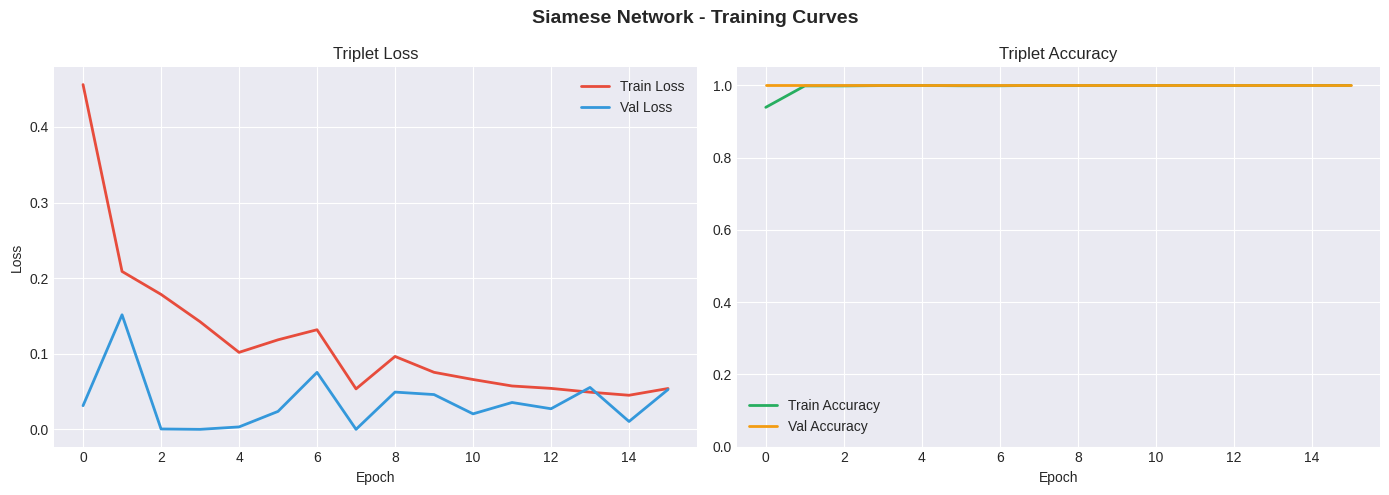

Saved siamese_far_frr.png


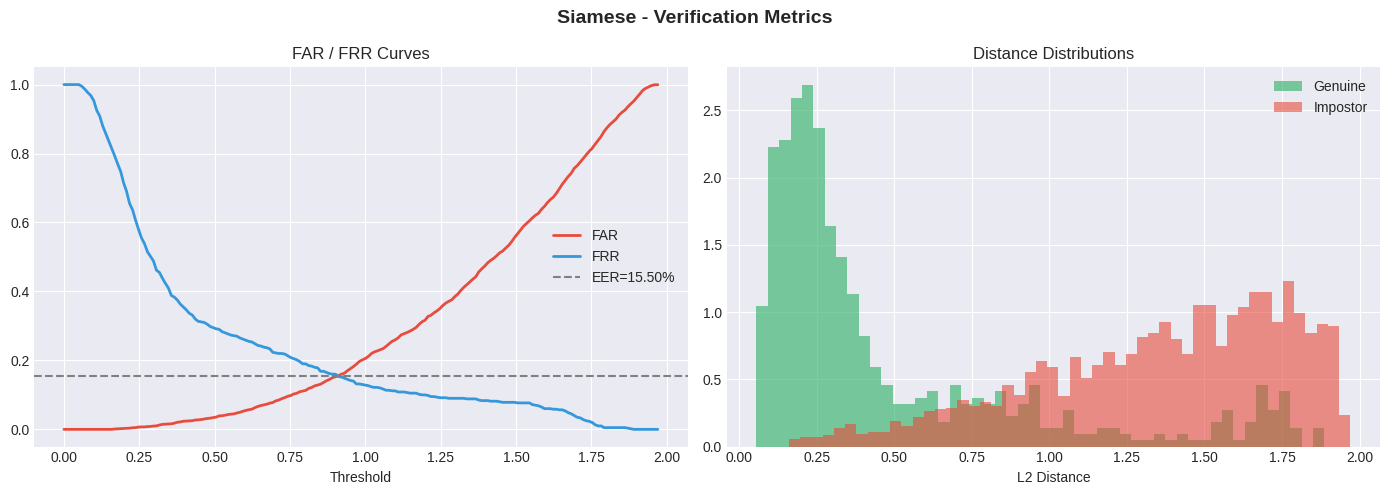

Saved siamese_roc.png


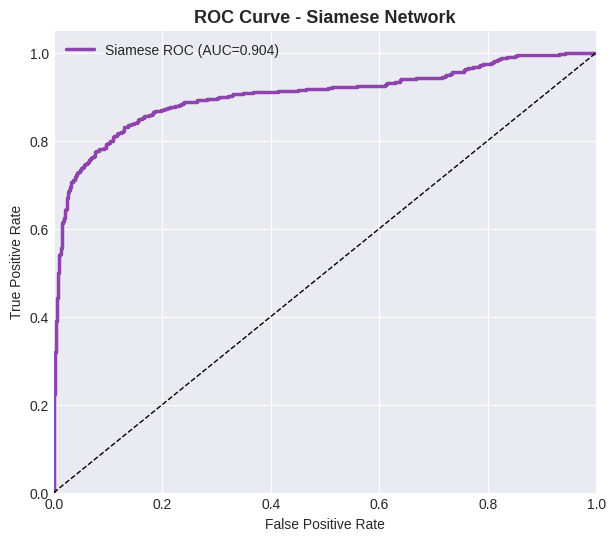

Saved pca_variance.png


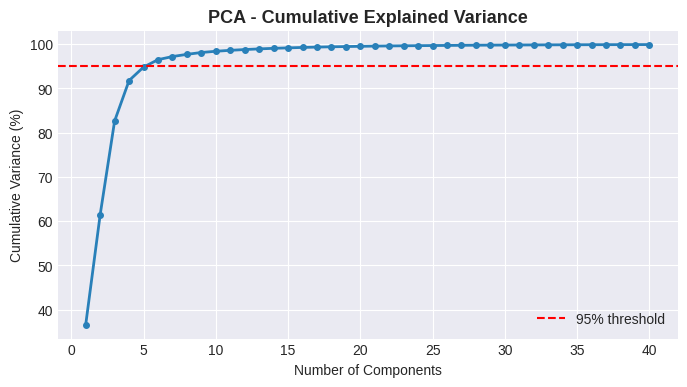

Saved tamper_training.png


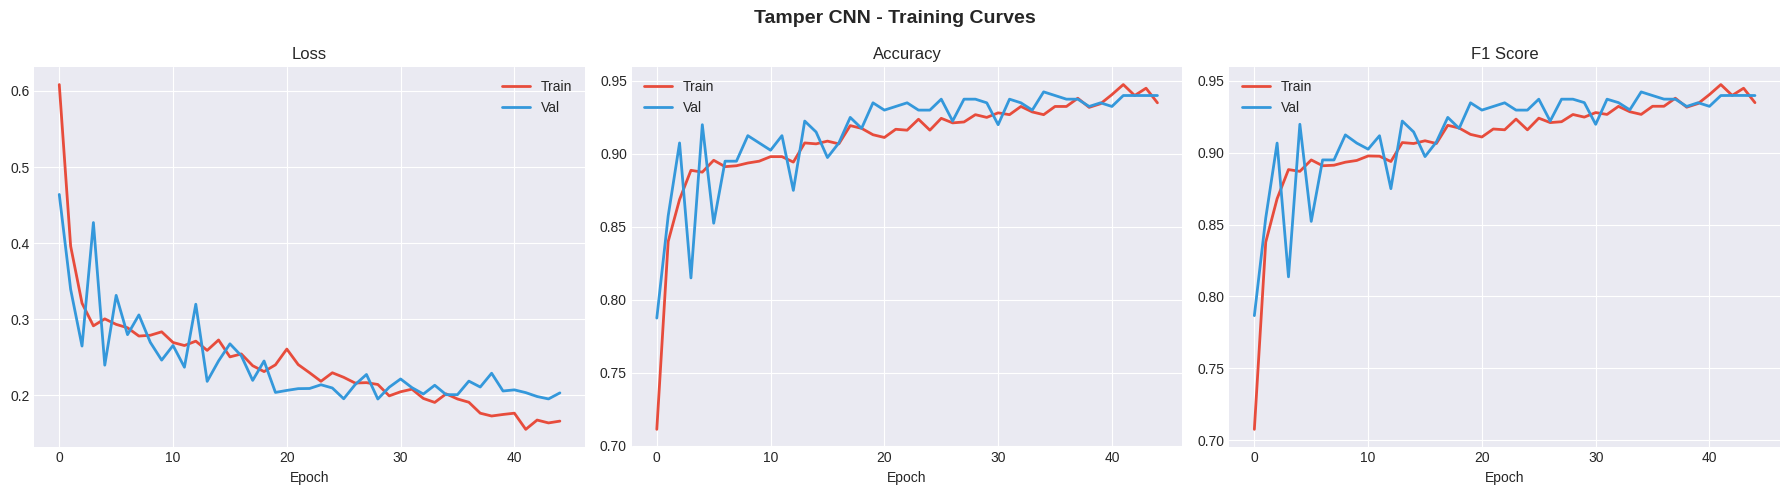

Saved tamper_eval.png


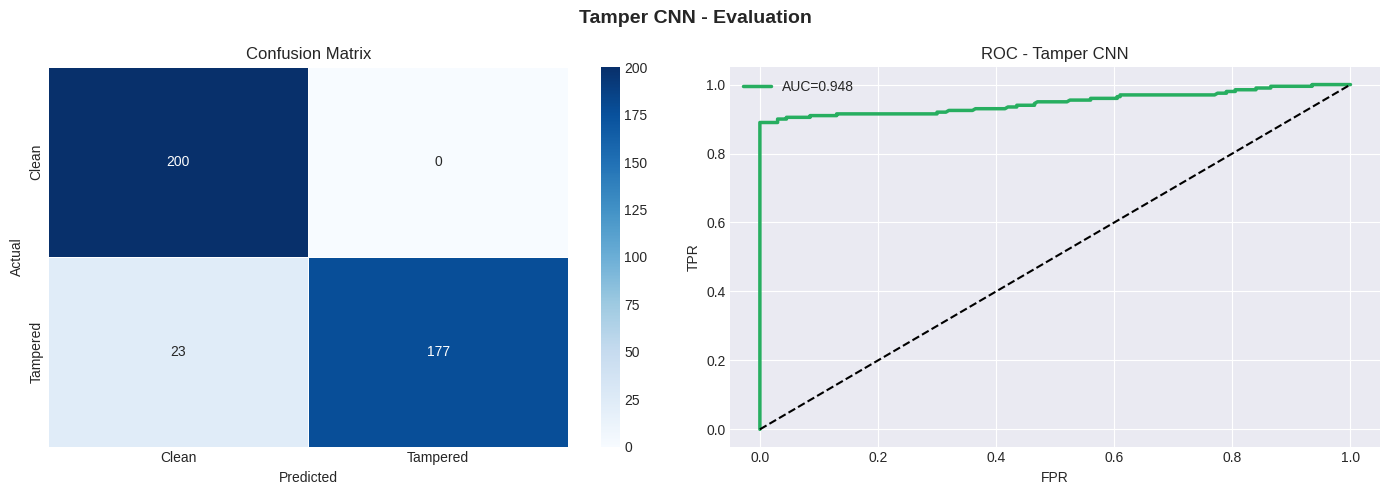


All plots saved to /content/results/


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

def save_fig(name):
    plt.savefig(str(RESULTS / name), dpi=150, bbox_inches='tight')
    print(f"Saved {name}")

# Figure 1: Siamese training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Siamese Network - Training Curves", fontsize=14, fontweight='bold')
axes[0].plot(siam_history['train_loss'], label='Train Loss', color='#E74C3C', linewidth=2)
axes[0].plot(siam_history['val_loss'],   label='Val Loss',   color='#3498DB', linewidth=2)
axes[0].set_title("Triplet Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].plot(siam_history['train_acc'], label='Train Accuracy', color='#27AE60', linewidth=2)
axes[1].plot(siam_history['val_acc'],   label='Val Accuracy',   color='#F39C12', linewidth=2)
axes[1].set_title("Triplet Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1.05); axes[1].legend()
plt.tight_layout(); save_fig("siamese_training.png"); plt.show()

# Figure 2: FAR / FRR / EER + distance distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Siamese - Verification Metrics", fontsize=14, fontweight='bold')
thresholds = np.linspace(0, max(distances_genuine + distances_impostor), 200)
FAR_pts = [np.mean(np.array(distances_impostor) < t) for t in thresholds]
FRR_pts = [np.mean(np.array(distances_genuine) >= t) for t in thresholds]
axes[0].plot(thresholds, FAR_pts, label='FAR', color='#E74C3C', linewidth=2)
axes[0].plot(thresholds, FRR_pts, label='FRR', color='#3498DB', linewidth=2)
axes[0].axhline(eer, color='gray', linestyle='--', linewidth=1.5, label=f'EER={eer*100:.2f}%')
axes[0].set_title("FAR / FRR Curves"); axes[0].set_xlabel("Threshold"); axes[0].legend()
axes[1].hist(distances_genuine,  bins=50, alpha=0.6, color='#27AE60', label='Genuine',  density=True)
axes[1].hist(distances_impostor, bins=50, alpha=0.6, color='#E74C3C', label='Impostor', density=True)
axes[1].set_title("Distance Distributions"); axes[1].set_xlabel("L2 Distance"); axes[1].legend()
plt.tight_layout(); save_fig("siamese_far_frr.png"); plt.show()

# Figure 3: ROC Siamese
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color='#8E44AD', linewidth=2.5, label=f'Siamese ROC (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title("ROC Curve - Siamese Network", fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
save_fig("siamese_roc.png"); plt.show()

# Figure 4: PCA explained variance
fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#2980B9', linewidth=2, markersize=4)
ax.axhline(95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
ax.set_title("PCA - Cumulative Explained Variance", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Components"); ax.set_ylabel("Cumulative Variance (%)"); ax.legend()
save_fig("pca_variance.png"); plt.show()

# Figures 5 & 6: Tamper
if need_tamper and tamp_history['train_loss']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Tamper CNN - Training Curves", fontsize=14, fontweight='bold')
    pairs = [
        (tamp_history['train_loss'], tamp_history['val_loss'], "Loss"),
        (tamp_history['train_acc'],  tamp_history['val_acc'],  "Accuracy"),
        (tamp_history['train_f1'],   tamp_history['val_f1'],   "F1 Score"),
    ]
    for ax, (tr, vl, title) in zip(axes, pairs):
        ax.plot(tr, label='Train', color='#E74C3C', linewidth=2)
        ax.plot(vl, label='Val',   color='#3498DB', linewidth=2)
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
    plt.tight_layout(); save_fig("tamper_training.png"); plt.show()

    if cm is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Tamper CNN - Evaluation", fontsize=14, fontweight='bold')
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Clean', 'Tampered'], yticklabels=['Clean', 'Tampered'],
                    ax=axes[0], linewidths=0.5)
        axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
        axes[1].plot(fpr_t, tpr_t, color='#27AE60', linewidth=2.5, label=f'AUC={auc_t:.3f}')
        axes[1].plot([0, 1], [0, 1], 'k--'); axes[1].set_title("ROC - Tamper CNN")
        axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()
        plt.tight_layout(); save_fig("tamper_eval.png"); plt.show()

print("\nAll plots saved to /content/results/")


## Cell 11 - Save Models and Final Summary

In [ ]:
meta = {
    "siamese": {
        "embed_dim": CFG['siam_embed_dim'],
        "img_size": CFG['img_size'],
        "best_val_loss": float(best_val_loss),
        "eer_percent": float(eer * 100),
        "roc_auc": float(roc_auc),
    },
    "tamper": {
        "accuracy": float(acc) if need_tamper else None,
        "f1": float(f1) if need_tamper else None,
        "auc": float(auc_t) if need_tamper else None,
    },
    "pca_components": CFG['pca_components'],
    "alpha": CFG['alpha'],
    "ngts": NGTS,
    "device": str(DEVICE),
}
with open(MODELS / 'metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("=" * 60)
print("SAVED MODEL FILES")
print("=" * 60)
for p in sorted(MODELS.iterdir()):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name:35s}  {size_mb:7.2f} MB")

print()
print("=" * 60)
print("FINAL METRICS SUMMARY")
print("=" * 60)
print(f"  [SIAMESE]  EER          : {eer*100:.2f}%")
print(f"  [SIAMESE]  ROC-AUC      : {roc_auc:.4f}")
if need_tamper:
    print(f"  [TAMPER]   Accuracy     : {acc*100:.2f}%")
    print(f"  [TAMPER]   F1 Score     : {f1:.4f}")
    print(f"  [TAMPER]   AUC          : {auc_t:.4f}")
print("=" * 60)
print("All models saved! Proceed to Cell 12 to start the API.")


SAVED MODEL FILES
  metadata.json                           0.00 MB
  pca_model.pkl                           0.05 MB
  siamese_best.pth                      142.17 MB
  tamper_best.pth                        45.36 MB

FINAL METRICS SUMMARY
  [SIAMESE]  EER          : 15.50%
  [SIAMESE]  ROC-AUC      : 0.9036
  [TAMPER]   Accuracy     : 94.25%
  [TAMPER]   F1 Score     : 0.9423
  [TAMPER]   AUC          : 0.9481
All models saved! Proceed to Cell 12 to start the API.


## Cell 12 - Flask API + ngrok
> **Step 1:** Go to https://dashboard.ngrok.com/get-started/your-authtoken and copy your token.
> **Step 2:** Paste it below replacing `PASTE_YOUR_NGROK_TOKEN_HERE`.
> **Step 3:** Run the cell. Copy the URL shown into your frontend `.env.local` as `VITE_API_URL=<url>`.
> **Keep this cell running!** Do not stop it.

### Default Admin Credentials
| Field | Value |
|-------|-------|
| Email | admin@sigauth.ai |
| Password | Admin@SigAuth2024 |

In [ ]:
import os, signal, subprocess

# Kill anything on port 5000
result = subprocess.run(['fuser', '-k', '5000/tcp'], capture_output=True)
print("Killed port 5000")

# Also kill old ngrok tunnels
try:
    from pyngrok import ngrok
    ngrok.kill()
    print("Killed ngrok")
except:
    pass

import time
time.sleep(2)
print("Ready — now run Cell 24")

Killed port 5000
Killed ngrok
Ready — now run Cell 24


In [ ]:
import threading, io, uuid
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf

# =========================================================
#  PASTE YOUR NGROK TOKEN HERE (get from ngrok.com/signup)
NGROK_TOKEN = "3AbqXqr3Q5SDKa5q7TSKmgrE7Qm_58BnuekC6Tffs3u3tEx93"
# =========================================================

print("Loading models for inference API...")
_siam = SiameseNet(embed_dim=CFG['siam_embed_dim']).to(DEVICE)
_siam.load_state_dict(torch.load(MODELS / 'siamese_best.pth', map_location=DEVICE)['model'])
_siam.eval()

_pca_data = joblib.load(MODELS / 'pca_model.pkl')

_tamp = None
if need_tamper and (MODELS / 'tamper_best.pth').exists():
    _tamp = TamperCNN().to(DEVICE)
    _tamp.load_state_dict(torch.load(MODELS / 'tamper_best.pth', map_location=DEVICE)['model'])
    _tamp.eval()

# ------------------------------------------------------------------
#  In-memory stores
# ------------------------------------------------------------------
USER_DB        = {}   # username (str) -> {"password": str, "email": str, "role": str, "id": str}
PERSON_DB      = {}   # person_name (str lowercase) -> embedding (np.ndarray)
VERIFY_HISTORY = []   # list of result dicts
TOKENS         = {}   # token (str) -> username (str)

# Seed the default admin account
_admin_id = str(uuid.uuid4())
USER_DB["admin@sigauth.ai"] = {
    "password": "Admin@SigAuth2024",
    "email":    "admin@sigauth.ai",
    "role":     "admin",
    "id":       _admin_id,
    "name":     "Admin",
}


# ------------------------------------------------------------------
#  Helper functions
# ------------------------------------------------------------------
def b64_to_tensor(b64_str):
    raw = base64.b64decode(b64_str.split(",")[-1])
    img = Image.open(io.BytesIO(raw)).convert("RGB")
    return val_tf(img).unsqueeze(0).to(DEVICE)

def get_embedding(tensor):
    with torch.no_grad():
        return _siam.get_embedding(tensor).cpu().numpy()[0]

def tamper_score(tensor):
    """Return raw tamper probability from TamperCNN. No dampening."""
    if _tamp is None:
        return 0.0
    with torch.no_grad():
        out = _tamp(tensor)
        probs = F.softmax(out, dim=1)
        # probs[:, 0] = clean, probs[:, 1] = tampered
        cnn_score = float(probs[:, 1].item())
    return round(cnn_score, 4)

def siamese_similarity(e1, e2):
    d = float(np.linalg.norm(e1 - e2))
    return round(float(np.exp(-d)), 4)

def pixel_features(tensor):
    img_np = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
    gray   = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    lap_var   = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    edges     = cv2.Canny(gray, 50, 150)
    edge_dens = float(edges.mean())
    buf       = cv2.imencode(".jpg", gray, [cv2.IMWRITE_JPEG_QUALITY, 85])[1]
    comp_ratio = len(buf) / (gray.size + 1e-9)
    return {
        "pixelAnomalies":       round(min(lap_var / 500.0, 1.0), 4),
        "edgeIrregularity":     round(min(edge_dens / 50.0, 1.0), 4),
        "compressionArtifacts": round(min(comp_ratio, 1.0), 4),
    }

def get_token_user(req):
    """Extract and validate Bearer token; return username or None."""
    auth = req.headers.get("Authorization", "")
    token = auth.replace("Bearer ", "").strip()
    return TOKENS.get(token)


# ------------------------------------------------------------------
#  Flask app
# ------------------------------------------------------------------
app = Flask(__name__)
CORS(app, resources={r"/*": {"origins": "*"}}, supports_credentials=True)


# ── Health ──────────────────────────────────────────────────────────
@app.route("/health")
def health():
    return jsonify({
        "status": "healthy",
        "device": str(DEVICE),
        "models": {"siamese": True, "tamper": _tamp is not None, "pca": True},
        "registered_users": len(PERSON_DB),
    })


# ── Auth: Login  (frontend calls POST /auth/login) ──────────────────
@app.route("/auth/login", methods=["POST", "OPTIONS"])
def auth_login():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d = request.get_json(force=True)
    email    = (d.get("email") or "").strip()
    password = (d.get("password") or "").strip()
    user = USER_DB.get(email)
    if user and user["password"] == password:
        token = str(uuid.uuid4())
        TOKENS[token] = email
        return jsonify({
            "success": True,
            "token":   token,
            "user": {
                "id":    user["id"],
                "email": user["email"],
                "name":  user.get("name", "Admin"),
                "role":  user["role"],
            }
        })
    return jsonify({"success": False, "message": "Invalid credentials"}), 401


# ── Auth: Signup  (frontend calls POST /auth/signup) ────────────────
@app.route("/auth/signup", methods=["POST", "OPTIONS"])
def auth_signup():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d = request.get_json(force=True)
    email    = (d.get("email") or "").strip()
    password = (d.get("password") or "").strip()
    name     = (d.get("name") or email.split("@")[0]).strip()
    if not email or not password:
        return jsonify({"success": False, "message": "email and password required"}), 400
    if email in USER_DB:
        return jsonify({"success": False, "message": "Account already exists"}), 409
    uid = str(uuid.uuid4())
    USER_DB[email] = {"password": password, "email": email, "role": "user", "id": uid, "name": name}
    token = str(uuid.uuid4())
    TOKENS[token] = email
    return jsonify({
        "success": True,
        "token":   token,
        "user": {"id": uid, "email": email, "name": name, "role": "user"}
    }), 201


# ── Auth: Profile  (frontend calls GET /auth/profile) ───────────────
@app.route("/auth/profile", methods=["GET", "OPTIONS"])
def auth_profile():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    email = get_token_user(request)
    if not email or email not in USER_DB:
        return jsonify({"success": False, "message": "Unauthorized"}), 401
    user = USER_DB[email]
    return jsonify({
        "success": True,
        "user": {"id": user["id"], "email": user["email"], "name": user.get("name"), "role": user["role"]}
    })


# ── Persons list  (frontend calls GET /persons) ──────────────────────
@app.route("/persons", methods=["GET", "OPTIONS"])
def get_persons():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    persons = [{"id": i+1, "name": name} for i, name in enumerate(PERSON_DB.keys())]
    return jsonify({"success": True, "persons": persons, "total": len(persons)})


# ── Add / register a person signature ───────────────────────────────
@app.route("/persons", methods=["POST"])
def add_person():
    d    = request.get_json(force=True)
    name = (d.get("name") or "").strip()
    b64  = d.get("signature") or d.get("signatureImage") or ""
    if not name or not b64:
        return jsonify({"success": False, "message": "name and signature required"}), 400
    try:
        t   = b64_to_tensor(b64)
        emb = get_embedding(t)
        PERSON_DB[name.lower()] = emb
        return jsonify({"success": True, "message": f"Registered {name}",
                        "person": {"id": len(PERSON_DB), "name": name}})
    except Exception as e:
        return jsonify({"success": False, "message": str(e)}), 500


# ── Admin: add_signature (legacy route kept for compatibility) ────────
@app.route("/admin/add_signature", methods=["POST"])
def add_signature():
    d    = request.get_json(force=True)
    name = (d.get("name") or "").strip()
    b64  = d.get("signature") or ""
    if not name or not b64:
        return jsonify({"success": False, "message": "name and signature required"}), 400
    try:
        t   = b64_to_tensor(b64)
        emb = get_embedding(t)
        PERSON_DB[name.lower()] = emb
        return jsonify({"success": True, "message": f"Registered {name}",
                        "users": list(PERSON_DB.keys())})
    except Exception as e:
        return jsonify({"success": False, "message": str(e)}), 500


# ── Admin: login (legacy route kept) ────────────────────────────────
@app.route("/admin/login", methods=["POST"])
def admin_login():
    d = request.get_json(force=True)
    email    = (d.get("email") or "").strip()
    password = (d.get("password") or "").strip()
    if email == "admin@sigauth.ai" and password == "Admin@SigAuth2024":
        token = str(uuid.uuid4())
        TOKENS[token] = email
        return jsonify({"success": True, "token": token})
    return jsonify({"success": False, "message": "Invalid credentials"}), 401


# ── Admin: users & history ───────────────────────────────────────────
@app.route("/admin/users")
def get_users():
    return jsonify({"users": list(PERSON_DB.keys())})

@app.route("/admin/history")
def get_history():
    return jsonify({"history": VERIFY_HISTORY[-100:]})

# ── Admin: logs (frontend calls GET /admin/logs) ─────────────────────
@app.route("/admin/logs", methods=["GET", "OPTIONS"])
def admin_logs():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    return jsonify({
        "success": True,
        "logs": VERIFY_HISTORY[-100:],
        "total": len(VERIFY_HISTORY)
    })

# ── Admin: signatures list (frontend calls GET /admin/signatures) ─────
@app.route("/admin/signatures", methods=["GET", "OPTIONS"])
def admin_signatures():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    sigs = [{"id": i+1, "name": name, "personName": name, "registeredAt": "2026-03-08"}
            for i, name in enumerate(PERSON_DB.keys())]
    return jsonify({"success": True, "signatures": sigs, "total": len(sigs)})

# ── Admin: add signature (frontend calls POST /admin/signatures/add) ──
@app.route("/admin/signatures/add", methods=["POST", "OPTIONS"])
def admin_signatures_add():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d    = request.get_json(force=True)
    name = (d.get("name") or d.get("personName") or "").strip()
    b64  = d.get("signature") or d.get("signatureImage") or ""
    if not name or not b64:
        return jsonify({"success": False, "message": "name and signature required"}), 400
    try:
        t   = b64_to_tensor(b64)
        emb = get_embedding(t)
        PERSON_DB[name.lower()] = emb
        return jsonify({"success": True, "message": f"Registered {name}",
                        "person": {"id": len(PERSON_DB), "name": name}})
    except Exception as e:
        return jsonify({"success": False, "message": str(e)}), 500

# ── Admin: delete signature ───────────────────────────────────────────
@app.route("/admin/signatures/<name>", methods=["DELETE", "OPTIONS"])
def admin_delete_signature(name):
    if request.method == "OPTIONS":
        return jsonify({}), 200
    key = name.strip().lower()
    if key in PERSON_DB:
        del PERSON_DB[key]
        return jsonify({"success": True, "message": f"Deleted {name}"})
    return jsonify({"success": False, "message": "Not found"}), 404

# ── Verification history (frontend calls GET /verifications) ─────────
@app.route("/verifications", methods=["GET", "OPTIONS"])
def get_verifications():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    return jsonify({"success": True, "history": VERIFY_HISTORY[-100:], "total": len(VERIFY_HISTORY)})


# ── Verify signature ─────────────────────────────────────────────────
# ── Mode 1: Forgery Detection (Siamese only — no tamper CNN) ─────────
@app.route("/verify/forgery", methods=["POST", "OPTIONS"])
def verify_forgery():
    """Checks if signature is AUTHENTIC or FORGED using Siamese model only."""
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d    = request.get_json(force=True)
    name = (d.get("person_name") or d.get("personName") or "").strip().lower()
    b64  = d.get("test_signature") or d.get("signature") or d.get("signatureImage") or ""
    if not b64:
        return jsonify({"error": "signature image required"}), 400
    try:
        t = b64_to_tensor(b64)
    except Exception as e:
        return jsonify({"error": f"Image decode error: {e}"}), 400

    pix_feats = pixel_features(t)
    test_emb  = get_embedding(t)

    sim  = 0.0
    if name and name in PERSON_DB:
        sim = siamese_similarity(test_emb, PERSON_DB[name])
    elif not name and PERSON_DB:
        sims = {n: siamese_similarity(test_emb, e) for n, e in PERSON_DB.items()}
        name = max(sims, key=sims.get)
        sim  = sims[name]

    result     = "authentic" if sim >= 0.72 else "forged"
    conf_score = round(sim, 4)

    record = {
        "id":           str(uuid.uuid4()),
        "mode":         "forgery",
        "person_name":  name or "unknown",
        "personName":   name or "unknown",
        "result":       result,
        "status":       result,
        "siameseScore": round(sim, 4),
        "tamperScore":  0.0,
        "confidence":   conf_score,
        "details": {
            "strokeConsistency": round(sim * 0.95, 4),
            "pressurePattern":   round(sim * 0.92, 4),
            "spatialAlignment":  round(sim * 0.97, 4),
            **pix_feats,
        },
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    VERIFY_HISTORY.append(record)
    return jsonify(record)


# ── Mode 2: Tamper Detection (TamperCNN only — no Siamese) ────────────
@app.route("/verify/tamper", methods=["POST", "OPTIONS"])
def verify_tamper():
    """Checks if signature image has been digitally tampered using CNN only."""
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d   = request.get_json(force=True)
    b64 = d.get("test_signature") or d.get("signature") or d.get("signatureImage") or ""
    if not b64:
        return jsonify({"error": "signature image required"}), 400
    try:
        t = b64_to_tensor(b64)
    except Exception as e:
        return jsonify({"error": f"Image decode error: {e}"}), 400

    t_score   = tamper_score(t)
    pix_feats = pixel_features(t)
    result    = "tampered" if t_score > 0.55 else "clean"

    record = {
        "id":           str(uuid.uuid4()),
        "mode":         "tamper",
        "person_name":  "N/A",
        "personName":   "N/A",
        "result":       result,
        "status":       result,
        "siameseScore": 0.0,
        "tamperScore":  round(t_score, 4),
        "confidence":   round(t_score if result == "tampered" else 1 - t_score, 4),
        "details": {
            "strokeConsistency": 0.0,
            "pressurePattern":   0.0,
            "spatialAlignment":  0.0,
            **pix_feats,
        },
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    VERIFY_HISTORY.append(record)
    return jsonify(record)


# ── Legacy /verify route — kept for compatibility, routes by mode param ──
@app.route("/verify", methods=["POST", "OPTIONS"])
def verify():
    if request.method == "OPTIONS":
        return jsonify({}), 200
    d    = request.get_json(force=True)
    mode = (d.get("mode") or "forgery").lower()
    # Route to the correct handler based on mode field
    if mode == "tamper":
        return verify_tamper()
    else:
        return verify_forgery()


# ------------------------------------------------------------------
def run_flask():
    app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)

conf.get_default().auth_token = NGROK_TOKEN
public_url = ngrok.connect(5000).public_url

print("=" * 60)
print(f"SigAuth API is LIVE at: {public_url}")
print("=" * 60)
print(f"  Health check  : {public_url}/health")
print(f"  Auth login    : POST {public_url}/auth/login")
print(f"  Auth signup   : POST {public_url}/auth/signup")
print(f"  Auth profile  : GET  {public_url}/auth/profile")
print(f"  Persons list  : GET  {public_url}/persons")
print(f"  Add person    : POST {public_url}/persons")
print(f"  Verify        : POST {public_url}/verify")
print(f"  History       : GET  {public_url}/verifications")
print()
print("Add this line to your frontend .env.local file:")
print(f"  VITE_API_URL={public_url}")
print()
print("Default admin credentials:")
print(f"  Email   : admin@sigauth.ai")
print(f"  Password: Admin@SigAuth2024")
print("=" * 60)
print("KEEP THIS CELL RUNNING! Do not interrupt.")

threading.Thread(target=run_flask, daemon=True).start()
time.sleep(86400)


Loading models for inference API...
SigAuth API is LIVE at: https://slaggier-ronna-unbrandied.ngrok-free.dev
  Health check  : https://slaggier-ronna-unbrandied.ngrok-free.dev/health
  Auth login    : POST https://slaggier-ronna-unbrandied.ngrok-free.dev/auth/login
  Auth signup   : POST https://slaggier-ronna-unbrandied.ngrok-free.dev/auth/signup
  Auth profile  : GET  https://slaggier-ronna-unbrandied.ngrok-free.dev/auth/profile
  Persons list  : GET  https://slaggier-ronna-unbrandied.ngrok-free.dev/persons
  Add person    : POST https://slaggier-ronna-unbrandied.ngrok-free.dev/persons
  Verify        : POST https://slaggier-ronna-unbrandied.ngrok-free.dev/verify
  History       : GET  https://slaggier-ronna-unbrandied.ngrok-free.dev/verifications

Add this line to your frontend .env.local file:
  VITE_API_URL=https://slaggier-ronna-unbrandied.ngrok-free.dev

Default admin credentials:
  Email   : admin@sigauth.ai
  Password: Admin@SigAuth2024
KEEP THIS CELL RUNNING! Do not interrupt

INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:41] "OPTIONS /auth/profile HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:41] "OPTIONS /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:41] "GET /auth/profile HTTP/1.1" 401 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:41] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:42] "OPTIONS /persons HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:42] "GET /persons HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:44] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:20:45] "GET /persons HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 18:21:06] "O